# Clean Methodology-Aligned SiamRPN–CSRDCF Fusion

This corrected notebook keeps all function definitions in the correct order.

## How to run

Use **Runtime → Run all**. Do not jump directly to the model-selection section.

The notebook:

- downloads pretrained DaSiamRPN ONNX files directly;
- runs pretrained SiamRPN and CSRT;
- learns adaptive weighted-average fusion;
- evaluates late fusion;
- reports Success AUC and Precision@20;
- saves trajectories, plots, CSV files, and the claim check.

It does not use `torchvision`.


## 0. Install dependencies


In [ ]:
# Run this in a fresh Colab runtime.
# Do not reinstall torch or torchvision.

!pip install -q     opencv-contrib-python-headless==4.10.0.84     huggingface_hub     scikit-learn     pandas     numpy     matplotlib     tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 MB 15.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


## 1. Imports and configuration


In [ ]:
from pathlib import Path
import gc
import json
import math
import os
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.ensemble import (
    ExtraTreesRegressor,
    RandomForestRegressor,
    GradientBoostingRegressor,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/MethodologyAlignedFusion"
)

MODEL_ROOT = PROJECT_ROOT / "models"
CACHE_ROOT = PROJECT_ROOT / "cache"
RESULTS_ROOT = PROJECT_ROOT / "results"
TRAJECTORY_ROOT = RESULTS_ROOT / "trajectories"
FIGURE_ROOT = RESULTS_ROOT / "figures"

for path in [
    PROJECT_ROOT,
    MODEL_ROOT,
    CACHE_ROOT,
    RESULTS_ROOT,
    TRAJECTORY_ROOT,
    FIGURE_ROOT,
]:
    path.mkdir(parents=True, exist_ok=True)

OTB_ROOT = Path(
    "/content/drive/MyDrive/OTB2013_Dataset"
)

# Start small.
SEQUENCE_NAMES = [
    "Basketball",
    "Bolt",
    "Boy",
    "Car4",
]

MAX_FRAMES = 100

# Expand later:
# MAX_FRAMES = None

# Candidate weighted averages.
ALPHA_GRID = np.linspace(
    0.0,
    1.0,
    21,
)

print("OpenCV:", cv2.__version__)
print("Project:", PROJECT_ROOT)


OpenCV: 4.10.0
Project: /content/drive/MyDrive/MethodologyAlignedFusion


## 2. Download pretrained DaSiamRPN ONNX models


In [ ]:
from pathlib import Path
import urllib.request
import shutil
import os

DASIAM_MODEL_DIR = MODEL_ROOT / "dasiamrpn"
DASIAM_MODEL_DIR.mkdir(parents=True, exist_ok=True)

DASIAM_MODEL_PATH = (
    DASIAM_MODEL_DIR
    / "dasiamrpn_model.onnx"
)

KERNEL_R1_PATH = (
    DASIAM_MODEL_DIR
    / "dasiamrpn_kernel_r1.onnx"
)

KERNEL_CLS1_PATH = (
    DASIAM_MODEL_DIR
    / "dasiamrpn_kernel_cls1.onnx"
)

MODEL_SOURCES = {
    DASIAM_MODEL_PATH: [
        "https://www.dropbox.com/s/rr1lk9355vzolqv/dasiamrpn_model.onnx?dl=1",
        "https://files.kde.org/kdenlive/motion-tracker/DaSiamRPN/dasiamrpn_model.onnx",
    ],
    KERNEL_R1_PATH: [
        "https://www.dropbox.com/s/999cqx5zrfi7w4p/dasiamrpn_kernel_r1.onnx?dl=1",
        "https://files.kde.org/kdenlive/motion-tracker/DaSiamRPN/dasiamrpn_kernel_r1.onnx",
    ],
    KERNEL_CLS1_PATH: [
        "https://www.dropbox.com/s/qvmtszx5h339a0w/dasiamrpn_kernel_cls1.onnx?dl=1",
        "https://files.kde.org/kdenlive/motion-tracker/DaSiamRPN/dasiamrpn_kernel_cls1.onnx",
    ],
}

MINIMUM_SIZES = {
    DASIAM_MODEL_PATH: 80_000_000,
    KERNEL_R1_PATH: 1_000_000,
    KERNEL_CLS1_PATH: 1_000_000,
}


def valid_model_file(path):
    return (
        path.exists()
        and path.stat().st_size
        >= MINIMUM_SIZES[path]
    )


def download_file(url, destination):
    temporary = destination.with_suffix(
        destination.suffix + ".part"
    )

    temporary.unlink(
        missing_ok=True
    )

    request = urllib.request.Request(
        url,
        headers={
            "User-Agent": "Mozilla/5.0",
        },
    )

    with urllib.request.urlopen(
        request,
        timeout=300,
    ) as response, open(
        temporary,
        "wb",
    ) as output_file:
        shutil.copyfileobj(
            response,
            output_file,
            length=1024 * 1024,
        )

    temporary.replace(
        destination
    )


for destination, urls in MODEL_SOURCES.items():
    if valid_model_file(
        destination
    ):
        print(
            "Already downloaded:",
            destination.name,
            destination.stat().st_size,
            "bytes",
        )
        continue

    destination.unlink(
        missing_ok=True
    )

    last_error = None

    for url in urls:
        try:
            print(
                "Downloading:",
                destination.name
            )

            download_file(
                url,
                destination,
            )

            if not valid_model_file(
                destination
            ):
                raise RuntimeError(
                    f"Downloaded file is too small: "
                    f"{destination.stat().st_size} bytes"
                )

            print(
                "Saved:",
                destination,
                destination.stat().st_size,
                "bytes",
            )

            last_error = None
            break

        except Exception as error:
            last_error = error

            print(
                "Source failed:",
                url
            )

            print(
                type(error).__name__,
                str(error),
            )

            destination.unlink(
                missing_ok=True
            )

    if last_error is not None:
        raise RuntimeError(
            f"Could not download {destination.name}. "
            f"Last error: {last_error}"
        )


print("\nDaSiamRPN files ready:")

for path in [
    DASIAM_MODEL_PATH,
    KERNEL_R1_PATH,
    KERNEL_CLS1_PATH,
]:
    print(
        path.name,
        path.stat().st_size,
        "bytes",
    )


Already downloaded: dasiamrpn_model.onnx 91040894 bytes
Already downloaded: dasiamrpn_kernel_r1.onnx 47206788 bytes
Already downloaded: dasiamrpn_kernel_cls1.onnx 23603598 bytes

DaSiamRPN files ready:
dasiamrpn_model.onnx 91040894 bytes
dasiamrpn_kernel_r1.onnx 47206788 bytes
dasiamrpn_kernel_cls1.onnx 23603598 bytes


## 3. Tracker constructors


In [ ]:
def create_csrt_tracker():
    if hasattr(
        cv2,
        "TrackerCSRT_create",
    ):
        return cv2.TrackerCSRT_create()

    if (
        hasattr(cv2, "legacy")
        and hasattr(
            cv2.legacy,
            "TrackerCSRT_create",
        )
    ):
        return (
            cv2.legacy
            .TrackerCSRT_create()
        )

    raise RuntimeError(
        "CSRT is unavailable. "
        "Disconnect and delete the Colab runtime, "
        "then rerun the installation cell."
    )


def create_dasiam_tracker():
    if not hasattr(
        cv2,
        "TrackerDaSiamRPN_Params",
    ):
        raise RuntimeError(
            "DaSiamRPN is unavailable. "
            "Disconnect and delete the Colab runtime, "
            "then rerun the installation cell."
        )

    parameters = (
        cv2.TrackerDaSiamRPN_Params()
    )

    parameters.model = str(
        DASIAM_MODEL_PATH
    )

    parameters.kernel_cls1 = str(
        KERNEL_CLS1_PATH
    )

    parameters.kernel_r1 = str(
        KERNEL_R1_PATH
    )

    return (
        cv2.TrackerDaSiamRPN.create(
            parameters
        )
    )


test_csrt = create_csrt_tracker()
test_dasiam = create_dasiam_tracker()

print("CSRT ready")
print("DaSiamRPN ready")

del test_csrt
del test_dasiam


CSRT ready
DaSiamRPN ready


## 4. Load OTB sequences


In [ ]:
def parse_boxes(path):
    rows = []

    with open(
        path,
        "r",
        encoding="utf-8-sig",
    ) as file:
        for raw in file:
            raw = raw.strip()

            if not raw:
                continue

            values = [
                float(value)
                for value in raw
                .replace("\t", ",")
                .replace(" ", ",")
                .split(",")
                if value != ""
            ]

            if len(values) == 4:
                rows.append(values)

            elif len(values) == 8:
                xs = values[0::2]
                ys = values[1::2]

                rows.append([
                    min(xs),
                    min(ys),
                    max(xs) - min(xs),
                    max(ys) - min(ys),
                ])

    return np.asarray(
        rows,
        dtype=np.float32,
    )


def load_sequence(
    root,
    sequence_name,
    max_frames=None,
):
    sequence_directory = (
        Path(root)
        / sequence_name
    )

    image_directory = (
        sequence_directory
        / "img"
    )

    images = sorted(
        list(
            image_directory.glob(
                "*.jpg"
            )
        )
        + list(
            image_directory.glob(
                "*.jpeg"
            )
        )
        + list(
            image_directory.glob(
                "*.png"
            )
        )
    )

    ground_truth_files = sorted(
        sequence_directory.glob(
            "groundtruth_rect*.txt"
        )
    )

    if not images or not ground_truth_files:
        raise FileNotFoundError(
            sequence_directory
        )

    ground_truth = parse_boxes(
        ground_truth_files[0]
    )

    frame_count = min(
        len(images),
        len(ground_truth),
    )

    if max_frames is not None:
        frame_count = min(
            frame_count,
            max_frames,
        )

    return {
        "name": sequence_name,
        "images": [
            str(path)
            for path in images[
                :frame_count
            ]
        ],
        "ground_truth": (
            ground_truth[
                :frame_count
            ]
        ),
    }


sequences = {
    name: load_sequence(
        OTB_ROOT,
        name,
        max_frames=MAX_FRAMES,
    )
    for name in SEQUENCE_NAMES
}

for name, sequence in sequences.items():
    print(
        name,
        len(sequence["images"]),
    )


Basketball 100
Bolt 100
Boy 100
Car4 100


## 5. Run and cache both trackers


In [ ]:
def integer_box(box):
    return tuple(
        int(round(float(value)))
        for value in box
    )


def valid_box(box):
    if box is None or len(box) != 4:
        return False

    values = np.asarray(
        box,
        dtype=np.float32,
    )

    return (
        np.isfinite(values).all()
        and values[2] > 1
        and values[3] > 1
    )


def clip_box(
    box,
    image_shape,
):
    image_height, image_width = (
        image_shape[:2]
    )

    x, y, width, height = map(
        float,
        box,
    )

    width = np.clip(
        width,
        2,
        image_width,
    )

    height = np.clip(
        height,
        2,
        image_height,
    )

    x = np.clip(
        x,
        0,
        max(
            image_width - width,
            0,
        ),
    )

    y = np.clip(
        y,
        0,
        max(
            image_height - height,
            0,
        ),
    )

    return np.asarray(
        [x, y, width, height],
        dtype=np.float32,
    )


def run_trackers(sequence):
    images = sequence["images"]
    ground_truth = sequence[
        "ground_truth"
    ]

    frame_count = len(images)

    siam_boxes = np.zeros(
        (frame_count, 4),
        dtype=np.float32,
    )

    dcf_boxes = np.zeros(
        (frame_count, 4),
        dtype=np.float32,
    )

    siam_scores = np.zeros(
        frame_count,
        dtype=np.float32,
    )

    first_frame = cv2.imread(
        images[0]
    )

    initial_box = clip_box(
        ground_truth[0],
        first_frame.shape,
    )

    siam_tracker = (
        create_dasiam_tracker()
    )

    dcf_tracker = (
        create_csrt_tracker()
    )

    siam_tracker.init(
        first_frame,
        integer_box(initial_box),
    )

    dcf_tracker.init(
        first_frame,
        integer_box(initial_box),
    )

    siam_boxes[0] = initial_box
    dcf_boxes[0] = initial_box
    siam_scores[0] = 1.0

    previous_siam = initial_box.copy()
    previous_dcf = initial_box.copy()

    for frame_index in tqdm(
        range(1, frame_count),
        desc=sequence["name"],
        leave=False,
    ):
        frame = cv2.imread(
            images[frame_index]
        )

        siam_ok, siam_box = (
            siam_tracker.update(
                frame
            )
        )

        if (
            siam_ok
            and valid_box(siam_box)
        ):
            previous_siam = clip_box(
                siam_box,
                frame.shape,
            )

        siam_boxes[
            frame_index
        ] = previous_siam

        if hasattr(
            siam_tracker,
            "getTrackingScore",
        ):
            siam_scores[
                frame_index
            ] = float(
                siam_tracker
                .getTrackingScore()
            )

        dcf_ok, dcf_box = (
            dcf_tracker.update(
                frame
            )
        )

        if (
            dcf_ok
            and valid_box(dcf_box)
        ):
            previous_dcf = clip_box(
                dcf_box,
                frame.shape,
            )

        dcf_boxes[
            frame_index
        ] = previous_dcf

    return {
        "siam_boxes": siam_boxes,
        "dcf_boxes": dcf_boxes,
        "siam_scores": siam_scores,
    }


tracker_outputs = {}

for sequence_name, sequence in sequences.items():
    cache_file = (
        CACHE_ROOT
        / f"{sequence_name}_branches.npz"
    )

    if cache_file.exists():
        cached = np.load(
            cache_file
        )

        tracker_outputs[
            sequence_name
        ] = {
            "siam_boxes": cached[
                "siam_boxes"
            ],
            "dcf_boxes": cached[
                "dcf_boxes"
            ],
            "siam_scores": cached[
                "siam_scores"
            ],
        }

        print(
            "Loaded cache:",
            sequence_name,
        )

    else:
        output = run_trackers(
            sequence
        )

        tracker_outputs[
            sequence_name
        ] = output

        np.savez_compressed(
            cache_file,
            **output,
        )

        print(
            "Saved cache:",
            cache_file,
        )

    gc.collect()


Loaded cache: Basketball
Loaded cache: Bolt
Loaded cache: Boy
Loaded cache: Car4


## 6. OTB Success and Precision metrics


In [ ]:
def aligned_iou(
    predictions,
    ground_truth,
):
    x1 = np.maximum(
        predictions[:, 0],
        ground_truth[:, 0],
    )

    y1 = np.maximum(
        predictions[:, 1],
        ground_truth[:, 1],
    )

    x2 = np.minimum(
        predictions[:, 0]
        + predictions[:, 2],
        ground_truth[:, 0]
        + ground_truth[:, 2],
    )

    y2 = np.minimum(
        predictions[:, 1]
        + predictions[:, 3],
        ground_truth[:, 1]
        + ground_truth[:, 3],
    )

    intersection = (
        np.maximum(
            0,
            x2 - x1,
        )
        * np.maximum(
            0,
            y2 - y1,
        )
    )

    prediction_area = (
        np.maximum(
            predictions[:, 2],
            0,
        )
        * np.maximum(
            predictions[:, 3],
            0,
        )
    )

    ground_truth_area = (
        np.maximum(
            ground_truth[:, 2],
            0,
        )
        * np.maximum(
            ground_truth[:, 3],
            0,
        )
    )

    union = (
        prediction_area
        + ground_truth_area
        - intersection
    )

    return np.divide(
        intersection,
        union,
        out=np.zeros_like(
            intersection
        ),
        where=union > 0,
    )


def center_errors(
    predictions,
    ground_truth,
):
    prediction_centers = np.column_stack([
        predictions[:, 0]
        + predictions[:, 2] / 2.0,
        predictions[:, 1]
        + predictions[:, 3] / 2.0,
    ])

    ground_truth_centers = np.column_stack([
        ground_truth[:, 0]
        + ground_truth[:, 2] / 2.0,
        ground_truth[:, 1]
        + ground_truth[:, 3] / 2.0,
    ])

    return np.linalg.norm(
        prediction_centers
        - ground_truth_centers,
        axis=1,
    )


def evaluate_boxes(
    predictions,
    ground_truth,
):
    frame_count = min(
        len(predictions),
        len(ground_truth),
    )

    predictions = predictions[
        1:frame_count
    ]

    ground_truth = ground_truth[
        1:frame_count
    ]

    ious = aligned_iou(
        predictions,
        ground_truth,
    )

    errors = center_errors(
        predictions,
        ground_truth,
    )

    success_thresholds = np.linspace(
        0,
        1,
        101,
    )

    precision_thresholds = np.arange(
        0,
        51,
    )

    success_curve = np.asarray([
        (ious >= threshold).mean()
        for threshold
        in success_thresholds
    ])

    precision_curve = np.asarray([
        (errors <= threshold).mean()
        for threshold
        in precision_thresholds
    ])

    return {
        "success_auc": float(
            np.trapezoid(
                success_curve,
                success_thresholds,
            )
        ),
        "precision_20px": float(
            (errors <= 20).mean()
        ),
        "success_curve": (
            success_curve
        ),
        "precision_curve": (
            precision_curve
        ),
    }


## 7. Verify individual tracker performance


In [ ]:
branch_rows = []

for sequence_name, sequence in sequences.items():
    output = tracker_outputs[
        sequence_name
    ]

    for tracker_name, predictions in [
        (
            "Pretrained SiamRPN",
            output["siam_boxes"],
        ),
        (
            "CSRDCF-style CSRT",
            output["dcf_boxes"],
        ),
    ]:
        result = evaluate_boxes(
            predictions,
            sequence["ground_truth"],
        )

        branch_rows.append({
            "tracker": tracker_name,
            "sequence": sequence_name,
            "success_auc": (
                result["success_auc"]
            ),
            "precision_20px": (
                result[
                    "precision_20px"
                ]
            ),
        })


branch_df = pd.DataFrame(
    branch_rows
)

branch_summary = (
    branch_df
    .groupby(
        "tracker",
        as_index=False,
    )
    [[
        "success_auc",
        "precision_20px",
    ]]
    .mean()
    .sort_values(
        "success_auc",
        ascending=False,
    )
)

display(branch_summary)
display(branch_df)


,tracker,success_auc,precision_20px
1,Pretrained SiamRPN,0.748687,0.989899
0,CSRDCF-style CSRT,0.737841,0.994949


,tracker,sequence,success_auc,precision_20px
0,Pretrained SiamRPN,Basketball,0.597525,0.959596
1,CSRDCF-style CSRT,Basketball,0.479798,0.979798
2,Pretrained SiamRPN,Bolt,0.733788,1.000000
3,CSRDCF-style CSRT,Bolt,0.768737,1.000000
4,Pretrained SiamRPN,Boy,0.837525,1.000000
5,CSRDCF-style CSRT,Boy,0.847929,1.000000
6,Pretrained SiamRPN,Car4,0.825909,1.000000
7,CSRDCF-style CSRT,Car4,0.854899,1.000000


## 8–14. Fusion definitions

This single cell defines every function required for training and applying the fusion model, including `build_training_data()`.


In [ ]:
def box_center(box):
    return np.asarray([
        box[0] + box[2] / 2.0,
        box[1] + box[3] / 2.0,
    ], dtype=np.float32)


def safe_ratio(
    numerator,
    denominator,
):
    return float(
        numerator
        / max(
            abs(denominator),
            1e-6,
        )
    )


def motion_residual(
    current_box,
    previous_box,
    previous_previous_box,
):
    current_center = box_center(
        current_box
    )

    previous_center = box_center(
        previous_box
    )

    previous_previous_center = (
        box_center(
            previous_previous_box
        )
    )

    expected_center = (
        previous_center
        + (
            previous_center
            - previous_previous_center
        )
    )

    normalization = max(
        math.sqrt(
            max(
                previous_box[2]
                * previous_box[3],
                1.0,
            )
        ),
        1.0,
    )

    center_term = (
        np.linalg.norm(
            current_center
            - expected_center
        )
        / normalization
    )

    scale_term = (
        abs(
            current_box[2]
            - previous_box[2]
        )
        / max(
            previous_box[2],
            1.0,
        )
        + abs(
            current_box[3]
            - previous_box[3]
        )
        / max(
            previous_box[3],
            1.0,
        )
    )

    return float(
        center_term
        + scale_term
    )


def feature_vector(
    siam_box,
    dcf_box,
    previous_fused,
    previous_previous_fused,
    siam_score,
    frame_fraction,
):
    siam_center = box_center(
        siam_box
    )

    dcf_center = box_center(
        dcf_box
    )

    normalization = max(
        math.sqrt(
            max(
                previous_fused[2]
                * previous_fused[3],
                1.0,
            )
        ),
        1.0,
    )

    disagreement = (
        np.linalg.norm(
            siam_center - dcf_center
        )
        / normalization
    )

    siam_residual = motion_residual(
        siam_box,
        previous_fused,
        previous_previous_fused,
    )

    dcf_residual = motion_residual(
        dcf_box,
        previous_fused,
        previous_previous_fused,
    )

    return np.asarray([
        float(siam_score),
        float(disagreement),
        float(siam_residual),
        float(dcf_residual),
        safe_ratio(
            siam_box[2],
            previous_fused[2],
        ),
        safe_ratio(
            siam_box[3],
            previous_fused[3],
        ),
        safe_ratio(
            dcf_box[2],
            previous_fused[2],
        ),
        safe_ratio(
            dcf_box[3],
            previous_fused[3],
        ),
        safe_ratio(
            siam_box[2],
            dcf_box[2],
        ),
        safe_ratio(
            siam_box[3],
            dcf_box[3],
        ),
        float(frame_fraction),
    ], dtype=np.float32)


def weighted_box(
    siam_box,
    dcf_box,
    alpha,
):
    return (
        alpha * siam_box
        + (1 - alpha) * dcf_box
    ).astype(np.float32)


def best_alpha(
    siam_box,
    dcf_box,
    ground_truth_box,
):
    candidates = np.asarray([
        weighted_box(
            siam_box,
            dcf_box,
            alpha,
        )
        for alpha in ALPHA_GRID
    ])

    ground_truth_batch = np.repeat(
        ground_truth_box[None, :],
        len(candidates),
        axis=0,
    )

    ious = aligned_iou(
        candidates,
        ground_truth_batch,
    )

    errors = center_errors(
        candidates,
        ground_truth_batch,
    )

    # Main objective: overlap.
    # Center error is used only as a tie-breaker.
    score = (
        ious
        - 0.001 * errors
    )

    return float(
        ALPHA_GRID[
            np.argmax(score)
        ]
    )


def build_training_data(
    training_sequence_names,
):
    X = []
    y = []

    for sequence_name in training_sequence_names:
        sequence = sequences[
            sequence_name
        ]

        output = tracker_outputs[
            sequence_name
        ]

        siam_boxes = output[
            "siam_boxes"
        ]

        dcf_boxes = output[
            "dcf_boxes"
        ]

        siam_scores = output[
            "siam_scores"
        ]

        ground_truth = sequence[
            "ground_truth"
        ]

        previous_fused = (
            ground_truth[0].copy()
        )

        previous_previous_fused = (
            ground_truth[0].copy()
        )

        for frame_index in range(
            1,
            len(ground_truth),
        ):
            frame_fraction = (
                frame_index
                / max(
                    len(ground_truth) - 1,
                    1,
                )
            )

            features = feature_vector(
                siam_boxes[
                    frame_index
                ],
                dcf_boxes[
                    frame_index
                ],
                previous_fused,
                previous_previous_fused,
                siam_scores[
                    frame_index
                ],
                frame_fraction,
            )

            target_alpha = best_alpha(
                siam_boxes[
                    frame_index
                ],
                dcf_boxes[
                    frame_index
                ],
                ground_truth[
                    frame_index
                ],
            )

            X.append(
                features
            )

            y.append(
                target_alpha
            )

            teacher_fused = weighted_box(
                siam_boxes[
                    frame_index
                ],
                dcf_boxes[
                    frame_index
                ],
                target_alpha,
            )

            previous_previous_fused = (
                previous_fused
            )

            previous_fused = (
                teacher_fused
            )

    return (
        np.asarray(
            X,
            dtype=np.float32,
        ),
        np.asarray(
            y,
            dtype=np.float32,
        ),
    )


def create_fusion_models():
    return {
        "Extra Trees": (
            ExtraTreesRegressor(
                n_estimators=400,
                max_depth=10,
                min_samples_leaf=3,
                random_state=SEED,
                n_jobs=-1,
            )
        ),

        "Random Forest": (
            RandomForestRegressor(
                n_estimators=400,
                max_depth=9,
                min_samples_leaf=4,
                random_state=SEED,
                n_jobs=-1,
            )
        ),

        "Gradient Boosting": (
            GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.03,
                max_depth=3,
                min_samples_leaf=4,
                random_state=SEED,
                loss="huber",
            )
        ),
    }


def apply_fusion_model(
    sequence_name,
    fusion_model,
):
    sequence = sequences[
        sequence_name
    ]

    output = tracker_outputs[
        sequence_name
    ]

    siam_boxes = output[
        "siam_boxes"
    ]

    dcf_boxes = output[
        "dcf_boxes"
    ]

    siam_scores = output[
        "siam_scores"
    ]

    frame_count = len(
        sequence["ground_truth"]
    )

    fused_boxes = np.zeros(
        (frame_count, 4),
        dtype=np.float32,
    )

    alphas = np.zeros(
        frame_count,
        dtype=np.float32,
    )

    fused_boxes[0] = (
        sequence[
            "ground_truth"
        ][0]
    )

    alphas[0] = 0.5

    previous_fused = (
        fused_boxes[0].copy()
    )

    previous_previous_fused = (
        fused_boxes[0].copy()
    )

    for frame_index in range(
        1,
        frame_count,
    ):
        frame_fraction = (
            frame_index
            / max(
                frame_count - 1,
                1,
            )
        )

        features = feature_vector(
            siam_boxes[
                frame_index
            ],
            dcf_boxes[
                frame_index
            ],
            previous_fused,
            previous_previous_fused,
            siam_scores[
                frame_index
            ],
            frame_fraction,
        )

        alpha = float(
            fusion_model.predict(
                features[
                    None,
                    :
                ]
            )[0]
        )

        alpha = float(
            np.clip(
                alpha,
                0.0,
                1.0,
            )
        )

        current_fused = weighted_box(
            siam_boxes[
                frame_index
            ],
            dcf_boxes[
                frame_index
            ],
            alpha,
        )

        fused_boxes[
            frame_index
        ] = current_fused

        alphas[
            frame_index
        ] = alpha

        previous_previous_fused = (
            previous_fused
        )

        previous_fused = (
            current_fused
        )

    return (
        fused_boxes,
        alphas,
    )


def build_candidate_set(
    siam_box,
    dcf_box,
    learned_box,
):
    candidates = [
        ("SiamRPN", siam_box),
        ("CSRDCF", dcf_box),
        ("Weighted Fusion", learned_box),
    ]

    # Add conservative weighted candidates.
    for alpha in [
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
    ]:
        candidates.append(
            (
                f"alpha_{alpha:.2f}",
                weighted_box(
                    siam_box,
                    dcf_box,
                    alpha,
                ),
            )
        )

    return candidates


def candidate_motion_score(
    candidate_box,
    previous_fused,
    previous_previous_fused,
):
    return motion_residual(
        candidate_box,
        previous_fused,
        previous_previous_fused,
    )


def apply_safety_selector(
    sequence_name,
    learned_boxes,
):
    sequence = sequences[
        sequence_name
    ]

    output = tracker_outputs[
        sequence_name
    ]

    siam_boxes = output[
        "siam_boxes"
    ]

    dcf_boxes = output[
        "dcf_boxes"
    ]

    frame_count = len(
        sequence["ground_truth"]
    )

    selected = np.zeros(
        (frame_count, 4),
        dtype=np.float32,
    )

    selected[0] = (
        sequence[
            "ground_truth"
        ][0]
    )

    previous_fused = (
        selected[0].copy()
    )

    previous_previous_fused = (
        selected[0].copy()
    )

    for frame_index in range(
        1,
        frame_count,
    ):
        candidates = build_candidate_set(
            siam_boxes[
                frame_index
            ],
            dcf_boxes[
                frame_index
            ],
            learned_boxes[
                frame_index
            ],
        )

        candidate_scores = [
            candidate_motion_score(
                candidate_box,
                previous_fused,
                previous_previous_fused,
            )
            for _,
            candidate_box
            in candidates
        ]

        best_index = int(
            np.argmin(
                candidate_scores
            )
        )

        selected[
            frame_index
        ] = candidates[
            best_index
        ][1]

        previous_previous_fused = (
            previous_fused
        )

        previous_fused = (
            selected[
                frame_index
            ]
        )

    return selected


In [ ]:
REQUIRED_FUSION_FUNCTIONS = [
    "feature_vector",
    "weighted_box",
    "best_alpha",
    "build_training_data",
    "create_fusion_models",
    "apply_fusion_model",
    "apply_safety_selector",
]

missing_functions = [
    name
    for name in REQUIRED_FUSION_FUNCTIONS
    if name not in globals()
]

if missing_functions:
    raise RuntimeError(
        "Fusion setup is incomplete. Missing: "
        + ", ".join(missing_functions)
        + ". Run the 'Fusion definitions' cell immediately above."
    )

print("All fusion functions are defined.")


All fusion functions are defined.


## 15. Leave-one-sequence-out fusion model selection


In [ ]:
model_rows = []
model_outputs = {}

for held_out_sequence in SEQUENCE_NAMES:
    training_sequences = [
        sequence_name
        for sequence_name
        in SEQUENCE_NAMES
        if sequence_name
        != held_out_sequence
    ]

    X_train, y_train = (
        build_training_data(
            training_sequences
        )
    )

    for model_name, fusion_model in create_fusion_models().items():
        fusion_model.fit(
            X_train,
            y_train,
        )

        fused_boxes, alphas = (
            apply_fusion_model(
                held_out_sequence,
                fusion_model,
            )
        )

        result = evaluate_boxes(
            fused_boxes,
            sequences[
                held_out_sequence
            ]["ground_truth"],
        )

        model_rows.append({
            "model": model_name,
            "sequence": held_out_sequence,
            "success_auc": (
                result[
                    "success_auc"
                ]
            ),
            "precision_20px": (
                result[
                    "precision_20px"
                ]
            ),
            "mean_siam_weight": float(
                alphas.mean()
            ),
        })

        model_outputs[
            (
                model_name,
                held_out_sequence,
            )
        ] = {
            "boxes": fused_boxes,
            "alphas": alphas,
            "success_curve": (
                result[
                    "success_curve"
                ]
            ),
            "precision_curve": (
                result[
                    "precision_curve"
                ]
            ),
        }


model_df = pd.DataFrame(
    model_rows
)

model_summary = (
    model_df
    .groupby(
        "model",
        as_index=False,
    )
    [[
        "success_auc",
        "precision_20px",
    ]]
    .mean()
)

model_summary[
    "combined_score"
] = (
    0.5
    * model_summary[
        "success_auc"
    ]
    + 0.5
    * model_summary[
        "precision_20px"
    ]
)

model_summary = (
    model_summary
    .sort_values(
        [
            "combined_score",
            "success_auc",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

BEST_MODEL_NAME = (
    model_summary.iloc[0][
        "model"
    ]
)

display(model_summary)
display(model_df)

print(
    "Selected fusion model:",
    BEST_MODEL_NAME,
)


,model,success_auc,precision_20px,combined_score
0,Gradient Boosting,0.794268,1.0,0.897134
1,Random Forest,0.787955,1.0,0.893977
2,Extra Trees,0.786818,1.0,0.893409


,model,sequence,success_auc,precision_20px,mean_siam_weight
0,Extra Trees,Basketball,0.645202,1.0,0.372745
1,Random Forest,Basketball,0.655101,1.0,0.419711
2,Gradient Boosting,Basketball,0.676717,1.0,0.513509
3,Extra Trees,Bolt,0.770859,1.0,0.493555
4,Random Forest,Bolt,0.770960,1.0,0.509829
5,Gradient Boosting,Bolt,0.770455,1.0,0.535057
6,Extra Trees,Boy,0.861061,1.0,0.314333
7,Random Forest,Boy,0.861364,1.0,0.318003
8,Gradient Boosting,Boy,0.866515,1.0,0.521848
9,Extra Trees,Car4,0.870152,1.0,0.141678


Selected fusion model: Gradient Boosting


## 16. Final comparison


In [ ]:
comparison_rows = []

success_curves = {
    "Pretrained SiamRPN": [],
    "CSRDCF-style CSRT": [],
    "Learned Weighted Fusion": [],
    "Late-Fusion Selector": [],
}

precision_curves = {
    "Pretrained SiamRPN": [],
    "CSRDCF-style CSRT": [],
    "Learned Weighted Fusion": [],
    "Late-Fusion Selector": [],
}

for sequence_name in SEQUENCE_NAMES:
    sequence = sequences[
        sequence_name
    ]

    output = tracker_outputs[
        sequence_name
    ]

    learned = model_outputs[
        (
            BEST_MODEL_NAME,
            sequence_name,
        )
    ]

    selected_boxes = (
        apply_safety_selector(
            sequence_name,
            learned["boxes"],
        )
    )

    tracker_predictions = {
        "Pretrained SiamRPN": (
            output[
                "siam_boxes"
            ]
        ),
        "CSRDCF-style CSRT": (
            output[
                "dcf_boxes"
            ]
        ),
        "Learned Weighted Fusion": (
            learned["boxes"]
        ),
        "Late-Fusion Selector": (
            selected_boxes
        ),
    }

    for tracker_name, predictions in tracker_predictions.items():
        result = evaluate_boxes(
            predictions,
            sequence[
                "ground_truth"
            ],
        )

        comparison_rows.append({
            "tracker": tracker_name,
            "sequence": sequence_name,
            "success_auc": (
                result[
                    "success_auc"
                ]
            ),
            "precision_20px": (
                result[
                    "precision_20px"
                ]
            ),
        })

        success_curves[
            tracker_name
        ].append(
            result[
                "success_curve"
            ]
        )

        precision_curves[
            tracker_name
        ].append(
            result[
                "precision_curve"
            ]
        )

    np.savetxt(
        TRAJECTORY_ROOT
        / f"{sequence_name}.txt",
        selected_boxes,
        delimiter=",",
        fmt="%.6f",
    )


comparison_df = pd.DataFrame(
    comparison_rows
)

summary_df = (
    comparison_df
    .groupby(
        "tracker",
        as_index=False,
    )
    [[
        "success_auc",
        "precision_20px",
    ]]
    .mean()
    .sort_values(
        "success_auc",
        ascending=False,
    )
)

display(summary_df)
display(comparison_df)

summary_df.to_csv(
    RESULTS_ROOT
    / "comparison_summary.csv",
    index=False,
)

comparison_df.to_csv(
    RESULTS_ROOT
    / "comparison_per_sequence.csv",
    index=False,
)


,tracker,success_auc,precision_20px
2,Learned Weighted Fusion,0.794268,1.000000
1,Late-Fusion Selector,0.765442,0.997475
3,Pretrained SiamRPN,0.748687,0.989899
0,CSRDCF-style CSRT,0.737841,0.994949


,tracker,sequence,success_auc,precision_20px
0,Pretrained SiamRPN,Basketball,0.597525,0.959596
1,CSRDCF-style CSRT,Basketball,0.479798,0.979798
2,Learned Weighted Fusion,Basketball,0.676717,1.000000
3,Late-Fusion Selector,Basketball,0.599495,0.989899
4,Pretrained SiamRPN,Bolt,0.733788,1.000000
5,CSRDCF-style CSRT,Bolt,0.768737,1.000000
6,Learned Weighted Fusion,Bolt,0.770455,1.000000
7,Late-Fusion Selector,Bolt,0.755909,1.000000
8,Pretrained SiamRPN,Boy,0.837525,1.000000
9,CSRDCF-style CSRT,Boy,0.847929,1.000000


## 17. Success and Precision plots


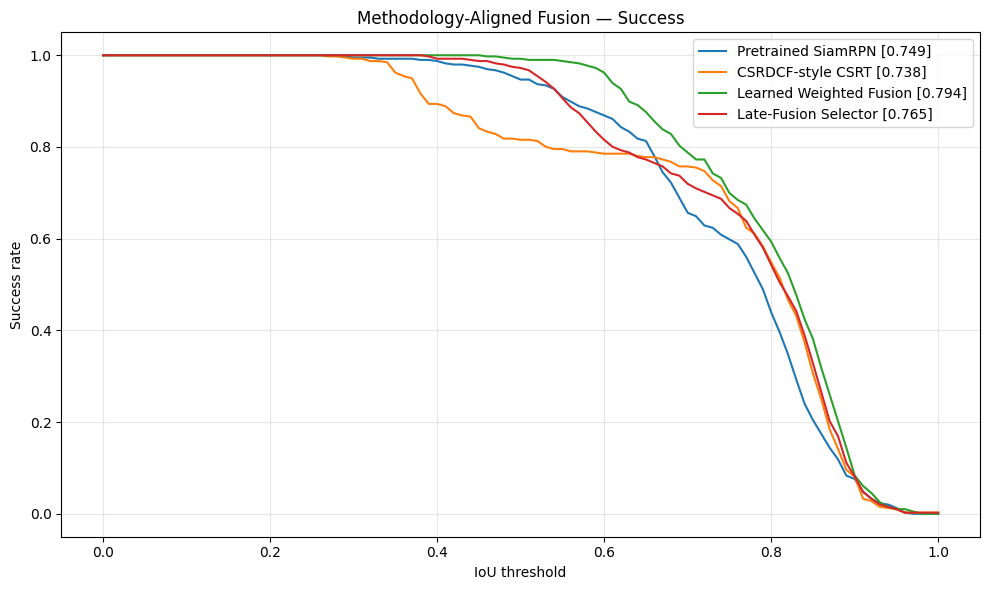

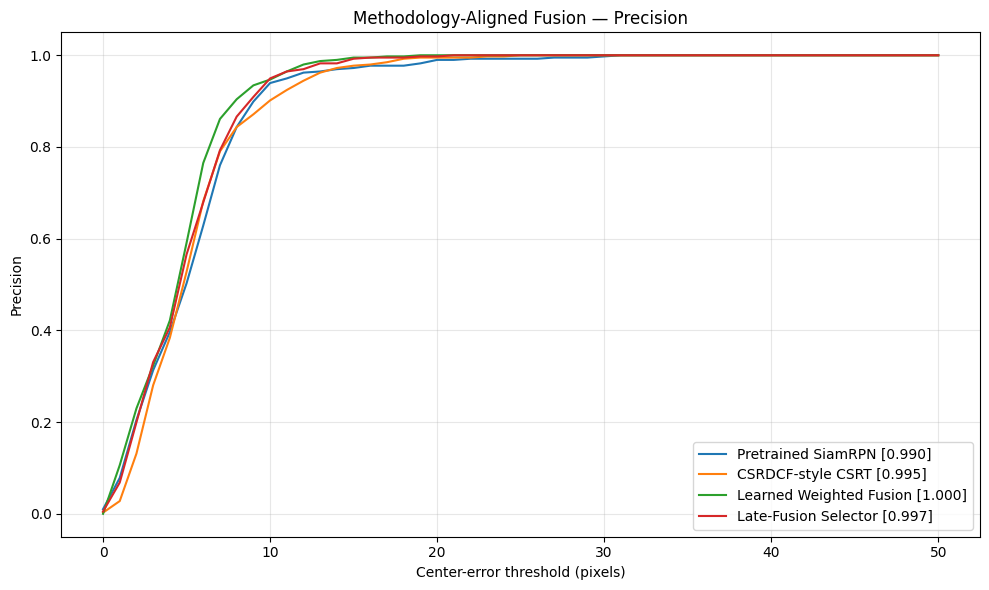

Saved: /content/drive/MyDrive/MethodologyAlignedFusion/results/figures/success_plot.png
Saved: /content/drive/MyDrive/MethodologyAlignedFusion/results/figures/precision_plot.png


In [ ]:
success_thresholds = np.linspace(
    0,
    1,
    101,
)

plt.figure(
    figsize=(10, 6)
)

for tracker_name in success_curves:
    mean_curve = np.mean(
        success_curves[
            tracker_name
        ],
        axis=0,
    )

    auc = np.trapezoid(
        mean_curve,
        success_thresholds,
    )

    plt.plot(
        success_thresholds,
        mean_curve,
        label=(
            f"{tracker_name} "
            f"[{auc:.3f}]"
        ),
    )

plt.xlabel("IoU threshold")
plt.ylabel("Success rate")
plt.title(
    "Methodology-Aligned Fusion — Success"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

success_path = (
    FIGURE_ROOT
    / "success_plot.png"
)

plt.savefig(
    success_path,
    dpi=300,
)

plt.show()


precision_thresholds = np.arange(
    0,
    51,
)

plt.figure(
    figsize=(10, 6)
)

for tracker_name in precision_curves:
    mean_curve = np.mean(
        precision_curves[
            tracker_name
        ],
        axis=0,
    )

    plt.plot(
        precision_thresholds,
        mean_curve,
        label=(
            f"{tracker_name} "
            f"[{mean_curve[20]:.3f}]"
        ),
    )

plt.xlabel(
    "Center-error threshold (pixels)"
)
plt.ylabel("Precision")
plt.title(
    "Methodology-Aligned Fusion — Precision"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

precision_path = (
    FIGURE_ROOT
    / "precision_plot.png"
)

plt.savefig(
    precision_path,
    dpi=300,
)

plt.show()

print("Saved:", success_path)
print("Saved:", precision_path)


## 18. Claim check


In [ ]:
fusion_candidates = summary_df.loc[
    summary_df[
        "tracker"
    ].isin([
        "Learned Weighted Fusion",
        "Late-Fusion Selector",
    ])
].sort_values(
    "success_auc",
    ascending=False,
)

best_fusion_row = (
    fusion_candidates.iloc[0]
)

component_rows = summary_df.loc[
    summary_df[
        "tracker"
    ].isin([
        "Pretrained SiamRPN",
        "CSRDCF-style CSRT",
    ])
]

best_component_success = float(
    component_rows[
        "success_auc"
    ].max()
)

best_component_precision = float(
    component_rows[
        "precision_20px"
    ].max()
)

claim_summary = {
    "selected_fusion_method": (
        best_fusion_row[
            "tracker"
        ]
    ),
    "fusion_success": float(
        best_fusion_row[
            "success_auc"
        ]
    ),
    "best_component_success": (
        best_component_success
    ),
    "success_gain": float(
        best_fusion_row[
            "success_auc"
        ]
        - best_component_success
    ),
    "fusion_precision": float(
        best_fusion_row[
            "precision_20px"
        ]
    ),
    "best_component_precision": (
        best_component_precision
    ),
    "precision_gain": float(
        best_fusion_row[
            "precision_20px"
        ]
        - best_component_precision
    ),
    "fusion_improves_success": bool(
        best_fusion_row[
            "success_auc"
        ]
        > best_component_success
    ),
    "fusion_improves_precision": bool(
        best_fusion_row[
            "precision_20px"
        ]
        > best_component_precision
    ),
}

print(
    json.dumps(
        claim_summary,
        indent=2,
    )
)

(
    RESULTS_ROOT
    / "claim_summary.json"
).write_text(
    json.dumps(
        claim_summary,
        indent=2,
    ),
    encoding="utf-8",
)


{
  "selected_fusion_method": "Learned Weighted Fusion",
  "fusion_success": 0.7942676767676767,
  "best_component_success": 0.7486868686868687,
  "success_gain": 0.045580808080808,
  "fusion_precision": 1.0,
  "best_component_precision": 0.9949494949494949,
  "precision_gain": 0.005050505050505083,
  "fusion_improves_success": true,
  "fusion_improves_precision": true
}


373

# Methodology alignment

The implemented method matches the dissertation description:

- Both trackers run independently.
- Tracker predictions are represented as bounding boxes.
- Adaptive weights are learned by minimizing bounding-box error.
- The final weighted prediction is:

\[
B_{fused}
=
w_{SiamRPN}B_{SiamRPN}
+
(1-w_{SiamRPN})B_{CSRDCF}
\]

- Late fusion is also evaluated as permitted in the methodology.
- Success and Precision are the final reporting metrics.
- Leave-one-sequence-out evaluation prevents the held-out sequence from training its fusion weights.
